In this example we are going to scrape board actions from the [Texas Medical Board](https://profile.tmb.state.tx.us/SearchBA.aspx). Unlike last time, we're doing to be downloading a bunch of PDFs with details!

Traditionally Python programmers use [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/) to scrape content from the interent. Instead of being *traditional*, we're going to use [Playwright](https://playwright.dev/python/), a **browser automation tool**! This means you actually control the browser! Filling out forms, clicking buttons, downloading documents... it's magic!!!✨✨✨

# Texas Medical Board Actions Details

- Filling out text inputs
- Inspecting the page
- Combining dataframes
- Looping through licenses
- Downloading PDFs (using Firefox)

## Installation

We need to install a few tools first! Remove the `#` and run the cell to install the Python packages and browsers that we'll need for our scraping adventure.

In [1]:
# %pip install --quiet lxml html5lib beautifulsoup4 pandas
# %pip install --quiet playwright
# !playwright install-deps
# !playwright install chromium firefox

And we'll set it up to be sure Playwright will work on Windows.

In [2]:
# Detect if we're running in Google Colab
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

import platform
import asyncio
import nest_asyncio

if platform.system() == "Windows":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
except RuntimeError:
    pass

## Opening up the browser and visiting our destination

We've been using Chromium (basically Chrome) for most of our exercises, but in this case we're using Firefox! Chromium for some reason sometimes gets blocked, while Firefox doesn't. Not sure why!

In [3]:
from playwright.async_api import async_playwright

# "Hey, open up a browser"
playwright = await async_playwright().start()

# Colab can't open a visible browser, so we run headless there
if IN_COLAB:
    use_headless = True
else:
    use_headless = False

browser = await playwright.firefox.launch(headless=use_headless)

# Create a new browser window
page = await browser.new_page()

In [4]:
await page.goto("https://profile.tmb.state.tx.us/SearchBA.aspx?eb2d4a70-6591-4ad4-ae6d-a2727e84cb39")

<Response url='https://profile.tmb.state.tx.us/SearchBA.aspx?eb2d4a70-6591-4ad4-ae6d-a2727e84cb39' request=<Request url='https://profile.tmb.state.tx.us/SearchBA.aspx?eb2d4a70-6591-4ad4-ae6d-a2727e84cb39' method='GET'>>

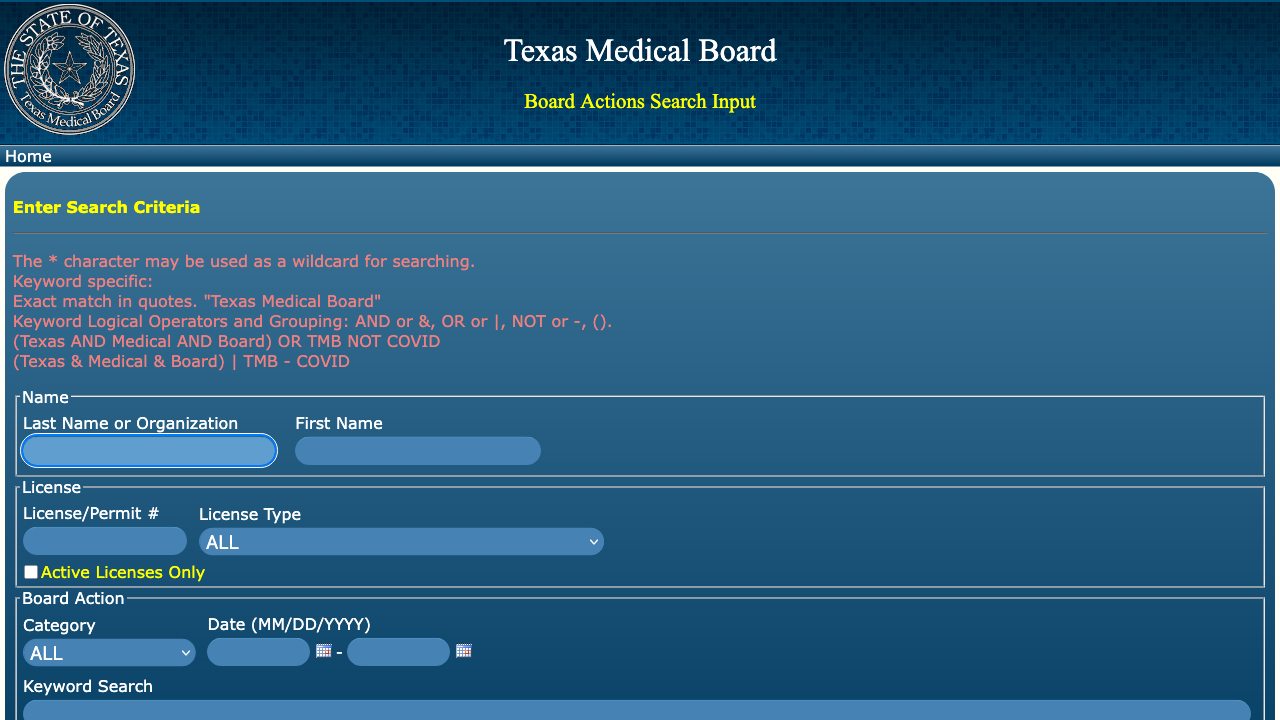

In [5]:
from IPython.display import Image

Image(await page.screenshot())

# Filling in a single license and searching

Filling in text fields, clicking, waiting for buttons to show up and clicking. Nothing crazy!

In [6]:
# M6992
# Q5611
# M1444
await page.locator("#BodyContent_tbLicense").fill("M6992")

In [7]:
await page.get_by_role("button", name="Search").click()

In [8]:
await page.get_by_text("Document").click()

### Opening up the documents section

In [9]:
await page.get_by_role("button", name="ExpandWeb Documents").wait_for()

In [10]:
await page.get_by_role("button", name="ExpandWeb Documents").click()

I dug into the code on the page and we have 3 links. 

In [11]:
links = page.locator(".doclink")
await links.count()

3

### Downloading one of the PDFs

By default this opens up in Chrome/Chromium as an in-page PDF. We change to Firefox to make it actually download.

In [12]:
from pathlib import Path

# Start waiting for the download
async with page.expect_download() as download_info:
    print("Clicking", await links.nth(1).inner_text())
    # Perform the action that initiates download
    await links.nth(1).click(force=True)
download = await download_info.value

filename = Path.home() / "Downloads" / download.suggested_filename
print("Saving as", filename)

# Wait for the download process to complete and save the downloaded file to "Downloads"
await download.save_as(filename)

Clicking 


Saving as /Users/soma/Downloads/0000FD89.PDF


### Return to the previous page

In [13]:
#await page.get_by_text("Back").click()
await page.get_by_role("link", name="Back").click()

## Putting it all together

If we had a CSV with licenses in it, we can read in the CSV file and extract a list of licenses.

In [14]:
import pandas as pd

df = pd.read_csv("licenses.csv")
df.head()

,Name,License,Type,Address,City,Board Actions
0,"HENSEN, ERIC LOGAN",R0868,Physician License,112 MEDICAL DR,PALESTINE,NaN
1,"CASTILLO, MARGUI",NONE,NaN,NaN,NaN,NaN
2,"HADEN, MARSHALL LYNN",BP10078006,Physician-in-Training Permit,6431 FANNIN ST,HOUSTON,NaN
3,"CHAVEZ, JORGE",NONE,NaN,NaN,NaN,NaN


In [15]:
licenses = df['License'].unique().tolist()

# We don't like the NONE one, so we'll remove it.
licenses.remove('NONE')
licenses

['R0868', 'BP10078006']

I don't think we have very many licenses in the CSV, so we'll try it again with a list of licenses that I put together manually.

In [ ]:
import time

licenses = ['M6992', 'Q5611', 'M1444']

output_dir = Path("downloads")
output_dir.mkdir(exist_ok=True)

for license in licenses:
    # Open a fresh browser window for each license so that
    # downloading files doesn't mess up the next search
    context = await browser.new_context()
    page = await context.new_page()

    print("Searching for", license)
    await page.goto("https://profile.tmb.state.tx.us/SearchBA.aspx?eb2d4a70-6591-4ad4-ae6d-a2727e84cb39")
    
    # Fill out license
    await page.locator("#BodyContent_tbLicense").fill(license)
    
    # Click search button
    await page.get_by_role("button", name="Search").click()
    
    # Move into Documents section
    await page.get_by_text("Document").click()
    
    # Expand documents tab
    await page.get_by_role("button", name="ExpandWeb Documents").wait_for()

    # Manually wait for it to open, ugh
    time.sleep(5)
    await page.get_by_role("button", name="ExpandWeb Documents").click()
    time.sleep(2)

    links = page.locator(".doclink")
    count = await links.count()
    print("Found", count, "documents")

    # Download all documents
    for i in range(count):
        # Wait for download
        print("Clicking", await links.nth(i).get_attribute("value"))
        async with page.expect_download() as download_info:
            await links.nth(i).click(force=True)
            download = await download_info.value

        filename = output_dir / download.suggested_filename
        print("Saving as", filename)

        # Wait for the download process to complete and save the downloaded file to "Downloads"
        await download.save_as(filename)

    # Close this window before opening the next one
    await context.close()

Searching for M6992


Found 3 documents
Clicking 8/20/2021


Saving as /Users/soma/Downloads/0000FD88.PDF


Clicking 8/20/2021


Saving as /Users/soma/Downloads/0000FD89.PDF


...

Saving as /Users/soma/Downloads/00010736.PDF


Searching for M1444


Found 2 documents
Clicking 3/3/2023
Saving as /Users/soma/Downloads/0000FC46.PDF


Clicking 1/17/2023


Saving as /Users/soma/Downloads/0000FC45.PDF
